# MLflow Lab 2 — Titanic Survival Prediction
**Course: IE-7374 MLOps | Professor Ramin Mohammadi**

This notebook demonstrates core MLflow concepts using the Titanic dataset:
- Experiment Tracking (params, metrics, artifacts)
- Logging multiple model runs for comparison
- Model Registry & Stage Transitions
- Loading production model for inference
- Serving the model via REST API

## Step 1: Install Dependencies

In [1]:
!pip install mlflow scikit-learn pandas numpy seaborn matplotlib cloudpickle requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.pyfunc
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import cloudpickle

print(f'MLflow version: {mlflow.__version__}')
print(f'Scikit-learn version: {sklearn.__version__}')

MLflow version: 3.11.1
Scikit-learn version: 1.8.0


## Step 3: Load Dataset

We use the Titanic dataset — a classic binary classification problem (Survived: 0/1).
Loaded directly from the seaborn library so there's no file dependency.

In [3]:
df = sns.load_dataset('titanic')
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 4: Exploratory Data Analysis

In [4]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

=== Missing Values ===
survived         0
pclass    

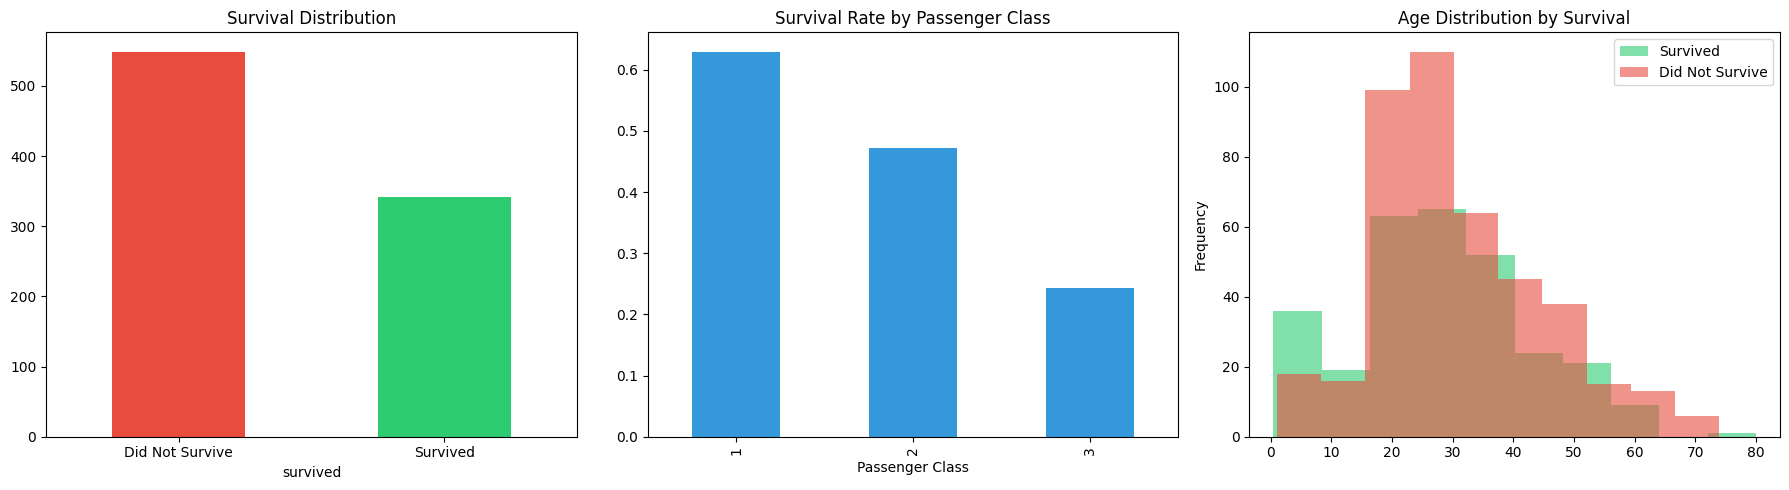

EDA plots saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival distribution
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'], rotation=0)

# Survival by class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')

# Age distribution by survival
df[df['survived'] == 1]['age'].dropna().plot(kind='hist', ax=axes[2], alpha=0.6, label='Survived', color='#2ecc71')
df[df['survived'] == 0]['age'].dropna().plot(kind='hist', ax=axes[2], alpha=0.6, label='Did Not Survive', color='#e74c3c')
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## Step 5: Data Preprocessing

In [6]:
def preprocess(df):
    data = df.copy()

    # Select useful features
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
    target = 'survived'
    data = data[features + [target]].copy()

    # Fill missing values
    data['age'].fillna(data['age'].median(), inplace=True)
    data['fare'].fillna(data['fare'].median(), inplace=True)
    data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

    # Encode categoricals
    data['sex'] = data['sex'].map({'male': 0, 'female': 1})
    data['embarked'] = data['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # Feature engineering
    data['family_size'] = data['sibsp'] + data['parch']
    data['is_alone'] = (data['family_size'] == 0).astype(int)

    return data

data = preprocess(df)
print(f'Preprocessed shape: {data.shape}')
print(f'Missing values: {data.isnull().sum().sum()}')
data.head()

Preprocessed shape: (891, 10)
Missing values: 0


,pclass,sex,age,sibsp,parch,fare,embarked,survived,family_size,is_alone
0,3,0,22.0,1,0,7.2500,0,0,1,0
1,1,1,38.0,1,0,71.2833,1,1,1,0
2,3,1,26.0,0,0,7.9250,0,1,0,1
3,1,1,35.0,1,0,53.1000,0,1,1,0
4,3,0,35.0,0,0,8.0500,0,0,0,1


## Step 6: Train/Validation/Test Split

In [7]:
X = data.drop('survived', axis=1)
y = data['survived']

# 60% train, 20% val, 20% test
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem)

print(f'Train size   : {X_train.shape[0]}')
print(f'Val size     : {X_val.shape[0]}')
print(f'Test size    : {X_test.shape[0]}')

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),   columns=X_val.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

Train size   : 534
Val size     : 178
Test size    : 179


## Step 7: MLflow Setup

Set the experiment name. MLflow will create a local `mlruns/` directory to store all run data.

In [8]:
mlflow.set_tracking_uri('mlruns')  # local tracking
EXPERIMENT_NAME = 'titanic_survival_prediction'
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'Experiment set: {EXPERIMENT_NAME}')

Experiment set: titanic_survival_prediction


## Step 8: Model Wrapper

Same pattern as Lab 2 — wrap sklearn model to expose `predict_proba` via MLflow's `PythonModel` interface.

In [9]:
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    """
    Wraps a sklearn classifier so that .predict() returns
    survival probability (class 1) instead of binary labels.
    """
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

print('ModelWrapper class defined.')

ModelWrapper class defined.


/Users/sanikakillekar/Documents/Northeastern/Ramin/LAB/MLOps/Labs/Airflow_Labs/Lab_1/.venv/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


## Step 9: Train & Log Multiple Models

We train 3 models — **Logistic Regression, Random Forest, Gradient Boosting** — and log each as a separate MLflow run. This lets us compare them side by side in the MLflow UI.

In [10]:
def log_model_run(run_name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, extra_params=None):
    """
    Trains a model and logs everything to MLflow:
    - Parameters
    - Metrics (AUC, Accuracy, F1)
    - EDA artifact
    - The model itself
    """
    with mlflow.start_run(run_name=run_name):

        # ---- Train ----
        model.fit(X_tr, y_tr)

        # ---- Metrics on validation set ----
        val_proba  = model.predict_proba(X_v)[:, 1]
        val_preds  = model.predict(X_v)
        val_auc    = roc_auc_score(y_v, val_proba)
        val_acc    = accuracy_score(y_v, val_preds)
        val_f1     = f1_score(y_v, val_preds)

        # ---- Metrics on test set ----
        test_proba = model.predict_proba(X_te)[:, 1]
        test_preds = model.predict(X_te)
        test_auc   = roc_auc_score(y_te, test_proba)
        test_acc   = accuracy_score(y_te, test_preds)
        test_f1    = f1_score(y_te, test_preds)

        # ---- Log params ----
        mlflow.log_param('model_type', run_name)
        mlflow.log_param('train_size', len(X_tr))
        mlflow.log_param('n_features', X_tr.shape[1])
        if extra_params:
            for k, v in extra_params.items():
                mlflow.log_param(k, v)

        # ---- Log metrics ----
        mlflow.log_metric('val_auc',   val_auc)
        mlflow.log_metric('val_acc',   val_acc)
        mlflow.log_metric('val_f1',    val_f1)
        mlflow.log_metric('test_auc',  test_auc)
        mlflow.log_metric('test_acc',  test_acc)
        mlflow.log_metric('test_f1',   test_f1)

        # ---- Log EDA artifact ----
        mlflow.log_artifact('eda_plots.png')

        # ---- Log confusion matrix as artifact ----
        cm = confusion_matrix(y_te, test_preds)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Confusion Matrix — {run_name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        cm_path = f'confusion_matrix_{run_name}.png'
        plt.savefig(cm_path, dpi=100, bbox_inches='tight')
        plt.close()
        mlflow.log_artifact(cm_path)

        # ---- Log model ----
        wrapped = SklearnModelWrapper(model)
        signature = infer_signature(X_tr, wrapped.predict(None, X_tr))
        mlflow.pyfunc.log_model(
            artifact_path='model',
            python_model=wrapped,
            signature=signature
        )

        print(f'[{run_name}] val_auc={val_auc:.4f} | test_auc={test_auc:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}')

    return test_auc

print('log_model_run() helper defined.')

log_model_run() helper defined.


In [11]:
results = {}

# --- Model 1: Logistic Regression ---
lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
results['logistic_regression'] = log_model_run(
    run_name='logistic_regression',
    model=lr,
    X_tr=X_train_scaled, y_tr=y_train,
    X_v=X_val_scaled,   y_v=y_val,
    X_te=X_test_scaled, y_te=y_test,
    extra_params={'C': 1.0, 'max_iter': 500}
)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
results['random_forest'] = log_model_run(
    run_name='random_forest',
    model=rf,
    X_tr=X_train, y_tr=y_train,
    X_v=X_val,   y_v=y_val,
    X_te=X_test, y_te=y_test,
    extra_params={'n_estimators': 100, 'max_depth': 6}
)

# --- Model 3: Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
results['gradient_boosting'] = log_model_run(
    run_name='gradient_boosting',
    model=gb,
    X_tr=X_train, y_tr=y_train,
    X_v=X_val,   y_v=y_val,
    X_te=X_test, y_te=y_test,
    extra_params={'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4}
)

print('\n=== All runs completed ===')
best_model_name = max(results, key=results.get)
print(f'Best model: {best_model_name} (AUC={results[best_model_name]:.4f})')

2026/04/11 08:49:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/11 08:49:19 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/04/11 08:49:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/11 08:49:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


[logistic_regression] val_auc=0.8805 | test_auc=0.8397 | test_acc=0.8156 | test_f1=0.7360


2026/04/11 08:49:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/11 08:49:23 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


[random_forest] val_auc=0.8693 | test_auc=0.8333 | test_acc=0.7709 | test_f1=0.6612


[gradient_boosting] val_auc=0.8505 | test_auc=0.8192 | test_acc=0.7821 | test_f1=0.6880

=== All runs completed ===
Best model: logistic_regression (AUC=0.8397)


## Step 10: Feature Importance (Random Forest & Gradient Boosting)

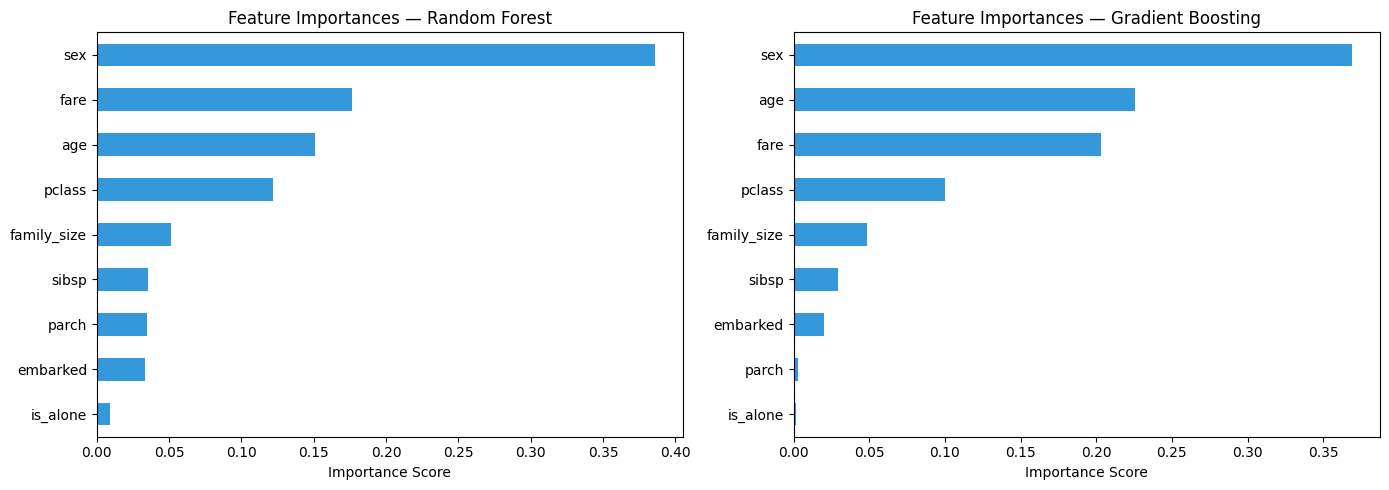

Feature importance plot saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(axes, [rf, gb], ['Random Forest', 'Gradient Boosting']):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances.sort_values().plot(kind='barh', ax=ax, color='#3498db')
    ax.set_title(f'Feature Importances — {title}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

## Step 11: Compare Runs in MLflow

We can query the MLflow tracking server programmatically to compare all runs.

In [13]:
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

comparison = runs_df[[
    'tags.mlflow.runName',
    'metrics.val_auc',
    'metrics.test_auc',
    'metrics.test_acc',
    'metrics.test_f1'
]].rename(columns={
    'tags.mlflow.runName': 'Model',
    'metrics.val_auc': 'Val AUC',
    'metrics.test_auc': 'Test AUC',
    'metrics.test_acc': 'Test Accuracy',
    'metrics.test_f1': 'Test F1'
}).sort_values('Test AUC', ascending=False)

print('=== Model Comparison ===')
print(comparison.to_string(index=False))

=== Model Comparison ===
              Model  Val AUC  Test AUC  Test Accuracy  Test F1
logistic_regression 0.880481  0.839657       0.815642 0.736000
logistic_regression 0.880481  0.839657       0.815642 0.736000
      random_forest 0.869318  0.833333       0.770950 0.661157
      random_forest 0.869318  0.833333       0.770950 0.661157
  gradient_boosting 0.850535  0.819236       0.782123 0.688000
  gradient_boosting 0.850535  0.819236       0.782123 0.688000


## Step 12: Register the Best Model in MLflow Model Registry

In [14]:
# Fetch run_id of best model
best_run = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string=f'tags.mlflow.runName = "{best_model_name}"'
).iloc[0]

best_run_id = best_run.run_id
print(f'Best run ID : {best_run_id}')
print(f'Best model  : {best_model_name}')

MODEL_REGISTRY_NAME = 'titanic_survival_model'

model_version = mlflow.register_model(
    model_uri=f'runs:/{best_run_id}/model',
    name=MODEL_REGISTRY_NAME
)

print(f'Registered model: {MODEL_REGISTRY_NAME} v{model_version.version}')
time.sleep(10)  # wait for registration to complete

Best run ID : a380feb2a32b46eb9a773547d0e6bb23
Best model  : logistic_regression


Registered model 'titanic_survival_model' already exists. Creating a new version of this model...
2026/04/11 08:49:25 WARNING mlflow.tracking._model_registry.fluent: Run with id a380feb2a32b46eb9a773547d0e6bb23 has no artifacts at artifact path 'model', registering model based on models:/m-a81cc0c17f474672b3296419f4355435 instead


Registered model: titanic_survival_model v2


Created version '2' of model 'titanic_survival_model'.


## Step 13: Transition Model to Production Stage

In [15]:
client = MlflowClient()

client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=model_version.version,
    stage='Production',
    archive_existing_versions=True  # archive any previous production versions
)

print(f'Model "{MODEL_REGISTRY_NAME}" v{model_version.version} transitioned to Production.')

# Add description tag
client.update_registered_model(
    name=MODEL_REGISTRY_NAME,
    description=f'Best model: {best_model_name}. Trained on Titanic dataset. Predicts survival probability.'
)

# Add tags
client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=model_version.version,
    key='dataset',
    value='titanic'
)
client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=model_version.version,
    key='selected_by',
    value='test_auc'
)

print('Model tags and description updated.')

Model "titanic_survival_model" v2 transitioned to Production.
Model tags and description updated.


## Step 14: Load Production Model & Run Inference

In [16]:
prod_model = mlflow.pyfunc.load_model(f'models:/{MODEL_REGISTRY_NAME}/Production')
print(f'Loaded production model: {MODEL_REGISTRY_NAME}/Production')

# Use unscaled test set (RF/GB don't need scaling; LR was logged with scaled data)
# For simplicity we use the raw test set — adjust if LR ends up as best
test_data = X_test if best_model_name != 'logistic_regression' else X_test_scaled

survival_probs = prod_model.predict(test_data)
survival_preds = (survival_probs >= 0.5).astype(int)

final_auc = roc_auc_score(y_test, survival_probs)
final_acc = accuracy_score(y_test, survival_preds)

print(f'\n=== Production Model Performance ===')
print(f'Test AUC      : {final_auc:.4f}')
print(f'Test Accuracy : {final_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, survival_preds, target_names=['Did Not Survive', 'Survived']))

Loaded production model: titanic_survival_model/Production

=== Production Model Performance ===
Test AUC      : 0.8397
Test Accuracy : 0.8156

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.91      0.86       110
       Survived       0.82      0.67      0.74        69

       accuracy                           0.82       179
      macro avg       0.82      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179



## Step 15: Sample Batch Inference

In [17]:
# Simulate new incoming passengers
new_passengers = pd.DataFrame({
    'pclass':      [1,   3,   2,   1,   3],
    'sex':         [1,   0,   1,   0,   1],  # 1=female, 0=male
    'age':         [29,  22,  35,  55,  18],
    'sibsp':       [0,   1,   0,   0,   2],
    'parch':       [0,   0,   1,   0,   1],
    'fare':        [211, 7.9, 26,  30,  14],
    'embarked':    [0,   0,   1,   0,   2],
    'family_size': [0,   1,   1,   0,   3],
    'is_alone':    [1,   0,   0,   1,   0]
})

probs = prod_model.predict(new_passengers.astype(float))
new_passengers['survival_probability'] = probs
new_passengers['prediction'] = (probs >= 0.5).astype(int)
new_passengers['prediction_label'] = new_passengers['prediction'].map({1: 'Survived', 0: 'Did Not Survive'})

print('=== Batch Inference Results ===')
print(new_passengers[['pclass', 'sex', 'age', 'fare', 'survival_probability', 'prediction_label']].to_string(index=False))

=== Batch Inference Results ===
 pclass  sex  age  fare  survival_probability prediction_label
      1    1   29 211.0          9.519012e-01         Survived
      3    0   22   7.9          2.268182e-07  Did Not Survive
      2    1   35  26.0          1.130347e-08  Did Not Survive
      1    0   55  30.0          1.378995e-13  Did Not Survive
      3    1   18  14.0          9.812800e-06  Did Not Survive


## Step 16: View All Registered Model Versions

In [18]:
print(f'=== Registered Versions of "{MODEL_REGISTRY_NAME}" ===')
for mv in client.search_model_versions(f"name='{MODEL_REGISTRY_NAME}'"):
    print(f'  Version {mv.version} | Stage: {mv.current_stage} | Run ID: {mv.run_id[:8]}...')

=== Registered Versions of "titanic_survival_model" ===
  Version 2 | Stage: Production | Run ID: a380feb2...
  Version 1 | Stage: Archived | Run ID: dbdc9271...


## Step 17: Serve the Model via REST API

Run the following command in your terminal to start the MLflow model server:

```bash
mlflow models serve -m models:/titanic_survival_model/Production -h 0.0.0.0 -p 5001 --no-conda
```

Once it's running, the cell below sends a real-time inference request.

In [19]:
import requests
import json

url = 'http://localhost:5001/invocations'

# Prepare payload
payload = {
    'dataframe_split': new_passengers.drop(
        columns=['survival_probability', 'prediction', 'prediction_label']
    ).to_dict(orient='split')
}

try:
    response = requests.post(url, json=payload, timeout=5)
    predictions = response.json()
    print('=== Real-time Inference Response ===')
    print(json.dumps(predictions, indent=2))
except requests.exceptions.ConnectionError:
    print('Model server not running. Start it with:')
    print('  mlflow models serve -m models:/titanic_survival_model/Production -h 0.0.0.0 -p 5001 --no-conda')
except Exception as e:
    print(f'Error: {e}')

Model server not running. Start it with:
  mlflow models serve -m models:/titanic_survival_model/Production -h 0.0.0.0 -p 5001 --no-conda


## Step 18: Launch MLflow UI

Run the following in your terminal to view all experiments, runs, metrics, and artifacts:

```bash
mlflow ui
```

Then open **http://localhost:5000** in your browser.

You'll be able to:
- Compare all 3 model runs side by side
- View logged params, metrics, artifacts (confusion matrices, EDA plots)
- See the Model Registry with the production model

## Summary

| MLflow Concept | Where Used |
|---|---|
| `mlflow.set_experiment` | Step 7 — named experiment |
| `mlflow.start_run` | Step 9 — one run per model |
| `mlflow.log_param` | Step 9 — model type, hyperparams |
| `mlflow.log_metric` | Step 9 — AUC, Accuracy, F1 (val + test) |
| `mlflow.log_artifact` | Step 9 — confusion matrix, EDA plots |
| `mlflow.pyfunc.log_model` | Step 9 — model + signature saved |
| `mlflow.search_runs` | Step 11 — compare all runs |
| `mlflow.register_model` | Step 12 — Model Registry |
| `client.transition_model_version_stage` | Step 13 — promote to Production |
| `mlflow.pyfunc.load_model` | Step 14 — load production model |
| `mlflow models serve` | Step 17 — REST API serving |